# Exploratory Data Analysis

This notebook investigates whether EEG band-power features differ systematically between the focus and distraction conditions, using session-level statistical testing.

## Statistical Analysis of EEG Power Differences Between Focus vs Distracted


EEG power features were computed across four channels (TP9, AF7, AF8, TP10) for three frequency bands (alpha, beta, theta) and derived measures (beta/alpha ratio, theta/alpha ratio, engagement index, and frontal alpha asymmetry). 

Data were recorded across 15 sessions and aggregated to session-level means prior to analysis. 

Based on signal quality metrics (variability, artifact rate, label balance, and signs of drowsiness), three sessions are identified as noisy and excluded to test whether results are sensitive to data quality.

Paired Wilcoxon signed-rank tests were conducted for each of the 29 features, with Benjamini-Hochberg false discovery rate (FDR) correction applied to account for multiple comparisons.

No features survived FDR correction (all adjusted p > 0.05), consistent with the limited statistical power inherent in a single-subject design with 15 observations. 

Nevertheless, several features demonstrated large effect sizes (rank-biserial correlation > 0.70) and uncorrected p-values below 0.10, suggesting meaningful trends that warrant discussion in the context of prior literature.

### Load processed data

In [1]:
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
DATA_PATH = PROJECT_ROOT / "data" / "processed_by_session" / "all_sessions_normalized.csv"
df = pd.read_csv(DATA_PATH)
df.head()

,TP9_theta,TP9_alpha,TP9_beta,TP9_theta_alpha,TP9_beta_alpha,TP9_engagement,AF7_theta,AF7_alpha,AF7_beta,AF7_theta_alpha,...,AF8_engagement,TP10_theta,TP10_alpha,TP10_beta,TP10_theta_alpha,TP10_beta_alpha,TP10_engagement,alpha_asymmetry,label,session
0,1.234471,1.210795,0.978582,0.982733,0.776915,0.851526,1.034322,0.765393,0.863495,1.222779,...,1.181369,1.001467,1.176479,1.089762,0.859498,0.898335,0.992781,-0.554765,1,1
1,0.678074,0.908069,1.327298,0.719753,1.405066,1.727267,0.988014,0.904989,0.983758,0.987863,...,1.013922,0.856766,0.952863,0.925597,0.907871,0.942069,1.016758,1.395709,1,1
2,1.099751,1.048086,1.468173,1.011400,1.346566,1.458644,1.030313,0.818970,1.020682,1.138356,...,0.987976,0.751295,0.777029,1.040647,0.976261,1.298846,1.356943,1.950642,1,1
3,1.033908,1.143660,1.233292,0.871385,1.036612,1.190827,0.743382,0.578643,0.873885,1.162460,...,0.700564,0.878124,0.996854,1.010756,0.889440,0.983345,1.070851,-3.202137,1,1
4,0.758928,1.115262,1.273642,0.655917,1.097786,1.390569,0.773703,0.711743,0.928365,0.983621,...,1.030596,0.823808,1.215817,0.876779,0.684149,0.699380,0.846399,-0.242200,1,1


### Remove data with high noise

### Session Exclusion Criteria

Sessions were flagged for exclusion if they met 2 or more of the following
a priori thresholds, computed during the session quality analysis:

- Mean coefficient of variation (CV) across features > 0.6
- Outlier rate (samples with any feature beyond 3σ) > 15%
- Label balance ratio (minority/majority class) < 0.6
- Mean theta/alpha ratio > 1.10 (possible drowsiness)

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/processed_by_session/all_sessions_normalized.csv")

feature_cols = [c for c in df.columns if c not in ['label', 'session']]
theta_alpha_cols = [c for c in feature_cols if 'theta_alpha' in c]

results = []

for session_id in sorted(df['session'].unique()):
    sub = df[df['session'] == session_id]
    
    # Mean CV
    cvs = []
    for col in feature_cols:
        mean_val = sub[col].mean()
        std_val = sub[col].std()
        cv = std_val / abs(mean_val) if mean_val != 0 else np.nan
        cvs.append(cv)
    mean_cv = np.nanmean(cvs)
    
    # Outlier Ratio (|zscore| > 3 sample proportion)
    z_scores = sub[feature_cols].apply(lambda col: np.abs((col - col.mean()) / col.std()))
    outlier_mask = (z_scores > 3).any(axis=1)
    outlier_rate = outlier_mask.mean()
    
    # Label imbalance (ratio: smaller / larger)
    label_counts = sub['label'].value_counts()
    label_ratio = label_counts.min() / label_counts.max()
    
    # Mean theta/alpha ratio
    theta_alpha_mean = sub[theta_alpha_cols].mean().mean()
    
    results.append({
        'session': session_id,
        'n_samples': len(sub),
        'mean_cv': round(mean_cv, 3),
        'outlier_rate': round(outlier_rate, 3),
        'label_ratio': round(label_ratio, 3),
        'theta_alpha_mean': round(theta_alpha_mean, 3),
    })

quality_df = pd.DataFrame(results)

# Flag sessions outside of threshold
quality_df['flag_cv']       = quality_df['mean_cv'] > 0.6
quality_df['flag_outlier']  = quality_df['outlier_rate'] > 0.15
quality_df['flag_imbalance'] = quality_df['label_ratio'] < 0.6
quality_df['flag_drowsy']   = quality_df['theta_alpha_mean'] > 1.1

quality_df['flag_count'] = quality_df[
    ['flag_cv', 'flag_outlier', 'flag_imbalance', 'flag_drowsy']
].sum(axis=1)

print(quality_df.to_string(index=False))

# Show sessions to remove
excluded_sessions = quality_df[quality_df['flag_count'] >= 2]['session'].tolist()
print(f"\nSessions to Remove: {excluded_sessions}")

 session  n_samples  mean_cv  outlier_rate  label_ratio  theta_alpha_mean  flag_cv  flag_outlier  flag_imbalance  flag_drowsy  flag_count
       1        282    0.342         0.181        0.880             1.038    False          True           False        False           1
       2        205    0.502         0.132        0.627             0.998    False         False           False        False           0
       3        242    0.524         0.153        0.984             1.069    False          True           False        False           1
       4        255    0.890         0.157        0.848             0.976     True          True           False        False           2
       5        297    0.402         0.125        0.980             1.040    False         False           False        False           0
       6        251    0.370         0.112        0.992             1.075    False         False           False        False           0
       7        163    0.374      

| Session | CV | Outlier % | Label ratio | θ/α | Flags |
|---------|-----|-----------|--------------|-----|-------|
| 4       | 0.89| 15.7%     | 85%          | 0.98| CV, outlier |
| 7       | 0.37| 12.9%     | 19%          | 1.12| label imbalance |
| 8       | 0.97| 11.6%     | 100%         | 1.14| CV, drowsy |

Based on this, sessions 4, 7, and 8 were excluded from the "clean" training subset.

In [3]:
df = df[~(df['session'] == 4) & ~(df['session'] == 7) & ~(df['session'] == 8)]
print(df['session'].unique())
print(len(df))

[ 1  2  3  5  6  9 10 11 12 13 14 15]
3112


### Separate by Session & Condition

In [4]:
session_means = df.groupby(["session", "label"]).mean().reset_index()
session_means


,session,label,TP9_theta,TP9_alpha,TP9_beta,TP9_theta_alpha,TP9_beta_alpha,TP9_engagement,AF7_theta,AF7_alpha,...,AF8_theta_alpha,AF8_beta_alpha,AF8_engagement,TP10_theta,TP10_alpha,TP10_beta,TP10_theta_alpha,TP10_beta_alpha,TP10_engagement,alpha_asymmetry
0,1,0,1.033274,0.949076,1.020978,1.121898,1.107842,1.142297,0.857378,0.758907,...,1.007413,0.989427,0.992052,0.906334,1.025127,1.032843,0.930681,1.023101,1.095592,-0.881224
1,1,1,1.149013,1.080596,1.414728,1.066874,1.367014,1.448447,0.844829,0.723270,...,1.057258,1.006863,0.987942,0.904722,0.992494,0.976557,0.967243,0.994562,1.044827,-0.934888
2,2,0,0.931136,1.035076,1.081403,0.993736,1.197362,1.195710,0.940352,1.007475,...,1.079538,1.054213,1.022848,0.983174,1.082688,1.028577,0.925755,1.015967,1.051194,0.805706
3,2,1,0.828198,0.920384,1.025372,0.950593,1.206621,1.236698,1.107588,1.030659,...,0.967557,0.946114,0.958973,1.162171,1.191687,0.984681,0.986897,0.873782,0.880517,-0.238918
4,3,0,0.914450,1.090076,1.091165,0.847951,1.116848,1.191616,1.291732,1.083151,...,1.113735,1.094388,1.072247,1.089619,0.956920,0.996973,1.163927,1.035615,0.960013,-2.043241
5,3,1,1.062464,1.198358,1.149826,0.890860,1.056771,1.097454,1.118754,0.956623,...,1.126585,1.156084,1.124578,1.043997,0.981183,1.027324,1.104387,1.053011,0.996054,0.027280
6,5,0,1.241602,1.252525,1.203909,1.029709,1.113208,1.059073,1.029243,1.005884,...,0.979908,1.014511,1.013579,0.893949,0.927785,0.959215,0.998664,1.116009,1.087222,0.022699
7,5,1,1.070839,1.103658,1.206912,0.990384,1.224828,1.198936,1.009582,1.031292,...,1.138687,1.073141,1.001741,0.964675,0.940682,0.950208,1.059978,1.088851,1.034947,2.467251
8,6,0,1.041828,1.099831,1.064420,1.068881,1.034917,1.045086,1.143726,1.118321,...,1.000952,1.019072,1.037512,1.160018,1.048072,1.089901,1.154695,1.063814,0.985080,1.007053
9,6,1,0.974023,1.087228,1.062499,1.006191,1.051480,1.091572,1.114349,1.087327,...,1.003925,1.046356,1.062153,1.092996,1.013507,1.053324,1.119863,1.076750,1.009953,1.507637


In [5]:
focus = session_means[session_means['label'] == 1].reset_index(drop=True)
dist = session_means[session_means['label'] == 0].reset_index(drop=True)

In [6]:
import numpy as np
from statsmodels.stats.multitest import multipletests
from scipy.stats import wilcoxon

results = []
feature_cols = [col for col in df.columns if col not in ['session', 'label']]
for col in feature_cols:
    f_vals = focus[col].values
    d_vals = dist[col].values
    stat, p = wilcoxon(f_vals, d_vals)

    n = len(f_vals)
    effect_size = 1 - (2 * stat) / (n * (n + 1))

    med_focus = np.median(f_vals)
    med_dist = np.median(d_vals)
    direction = "focus > distracted" if med_focus > med_dist else "distracted > focus"

    results.append({
        "feature":     col,
        "p_value":     p,
        "effect_size": round(effect_size, 3),
        "direction":   direction,
        "median_focus": round(med_focus, 4),
        "median_distracted": round(med_dist, 4)
    })

results_df = pd.DataFrame(results)

reject, p_corrected, _, _ = multipletests(results_df['p_value'], method='fdr_bh')
results_df['p_corrected'] = p_corrected.round(4)
results_df['significant'] = reject

print(results_df.sort_values('p_corrected').to_string(index=False))


         feature  p_value  effect_size          direction  median_focus  median_distracted  p_corrected  significant
        TP9_beta 0.063965        0.808 focus > distracted        1.0817             1.0526       0.3198        False
       TP10_beta 0.052246        0.821 distracted > focus        0.9904             1.0335       0.3198        False
       AF7_alpha 0.063965        0.808 distracted > focus        0.9835             1.0250       0.3198        False
        AF7_beta 0.020996        0.872 distracted > focus        0.9854             0.9995       0.3198        False
 TP10_engagement 0.042480        0.833 distracted > focus        1.0038             1.0431       0.3198        False
 TP10_beta_alpha 0.109863        0.769 focus > distracted        1.0521             1.0497       0.4578        False
 AF7_theta_alpha 0.129395        0.756 focus > distracted        1.1066             1.0605       0.4621        False
       AF8_theta 0.518555        0.615 focus > distracted       

## Results

### Features to highlight (p <0.1 & high effect size > 0.7)

In [7]:
results_df[(results_df['p_value'] < 0.10) & (results_df['effect_size'] > 0.7)].sort_values('p_value')

,feature,p_value,effect_size,direction,median_focus,median_distracted,p_corrected,significant
8,AF7_beta,0.020996,0.872,distracted > focus,0.9854,0.9995,0.3198,False
23,TP10_engagement,0.042480,0.833,distracted > focus,1.0038,1.0431,0.3198,False
20,TP10_beta,0.052246,0.821,distracted > focus,0.9904,1.0335,0.3198,False
2,TP9_beta,0.063965,0.808,focus > distracted,1.0817,1.0526,0.3198,False
7,AF7_alpha,0.063965,0.808,distracted > focus,0.9835,1.0250,0.3198,False


### Trends suggestive of prior research (not statistically significant after FDR correction)


While none of these features reached significance after multiple comparison correction (all p_corrected > 0.05), the direction of effect for several features aligns with established EEG literature.

- AF7 alpha power was higher in the distracted condition (p = 0.064, ES = 0.808), consistent with the well-documented phenomenon of frontal alpha suppression during focused cognitive states, where alpha power is thought to reflect cortical idling. 

- TP9 beta power was higher during focus (p = 0.064, ES = 0.808), in line with reports of beta being dominant during cognitive thinking. 

### Findings inconsistent with prior research

- AF7 beta (p = 0.021, ES = 0.872) 
- TP10 beta (p = 0.052, ES = 0.821)
- TP10 engagement index (p = 0.042, ES = 0.833)

The direction of AF7 beta is contrary to the typical finding of elevated frontal beta during focused cognitive states. However, the AF7 electrode sits in close proximity to the temporal muscle, making it particularly susceptible to electromyographic (EMG) artifact, especially during periods of heightened task-related tension or jaw clenching.

Similarly, the engagement index at TP10 behaving inversely may reflect individual differences in parietal lateralisation or asymmetric task-related activation not captured by the general literature.

Text(0.5, 1.0, 'Effect sizes by feature')

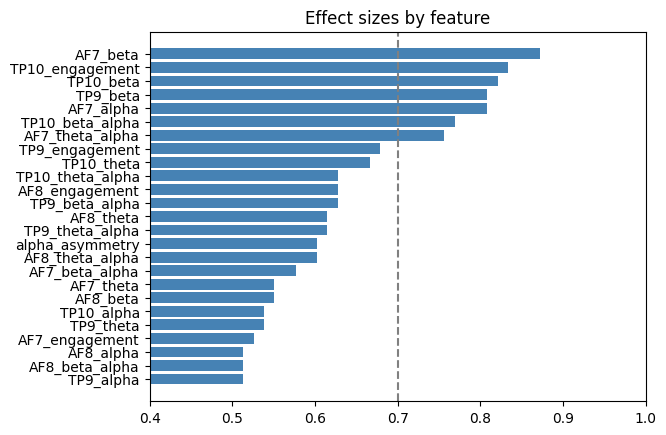

In [8]:
import matplotlib.pyplot as plt

plt.barh(results_df.sort_values('effect_size')['feature'], results_df.sort_values('effect_size')['effect_size'], color='steelblue')
plt.axvline(0.7, color='gray', linestyle='--')
plt.xlim(0.4, 1.0)
plt.title('Effect sizes by feature')

### Limitations

This analysis is based on a single participant, limiting the generalisability of findings. 

The Wilcoxon signed-rank test with n=15 sessions provides approximately 40–50% power to detect medium-to-large effects, meaning that genuine differences may remain undetected. 

Additionally, while baseline normalisation was applied, residual session-to-session variability in signal quality may have contributed to noise. 

Future work with a larger participant sample, or additional recording sessions, would substantially increase statistical power and the interpretability of these results.